# Exploration of HDB Resale Transactions in Singapore
## Introduction

### EDA
A data science project often begins with Exploratory Data Analysis (EDA). We use EDA to find patterns, unusual things, and interesting clues that are hiding in the data. EDA provides insight about the data and helps us come up with plans for tackling our data science project.

### HDB
In Singapore, HDBs (Housing and Development Board flats) are homes that the majority of people live in. They are apartments or flats that the government builds and rents or sells to Singaporeans. These homes provide affordable housing for many Singaporeans and offer various facilities and amenities like parks, schools, and markets nearby.

### This Project 
This project aims to build a model that allows you to choose a HDB on a map and predict the current resale price of it based on historical trends + other data such as amenity information.

## Loading the Data 

In [1]:
# DATA MANIPULATION
import pandas as pd
import numpy as np
#import statsmodels

# DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import os

In [2]:
# Navigate to your project
os.chdir('/workspaces/DSE3101-Project')

# Verify you're in the right place
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder
os.chdir('data/raw')


Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', '.DS_Store', 'models', 'frontend', 'requirements.txt', '.gitignore', '.vscode', 'backend', 'data', 'onemap_all_themes_full.json', 'README.md', 'onemap_all_themes_raw.txt']


In [3]:
df = pd.read_csv('HDB_full_resale_info.csv.gz')

# Check to see if it loaded correctly
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259143 entries, 0 to 259142
Data columns (total 37 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   town                               259143 non-null  str    
 1   flat_type                          259143 non-null  str    
 2   block                              259143 non-null  str    
 3   street_name                        259143 non-null  str    
 4   storey_range                       259143 non-null  str    
 5   floor_area_sqm                     259143 non-null  float64
 6   flat_model                         259143 non-null  str    
 7   lease_commence_date                259143 non-null  int64  
 8   resale_price                       259143 non-null  float64
 9   remaining_lease                    259143 non-null  int64  
 10  sold_year                          259143 non-null  int64  
 11  address                            259143 non-null

In [16]:
print("=" * 80)
print(f"Basic statistics for numerical variables:")
print("=" * 80)
df.describe().T

Basic statistics for numerical variables:


,count,mean,std,min,25%,50%,75%,max
floor_area_sqm,259143.0,96.892037,24.046592,31.000000,81.000000,93.000000,112.000000,3.667000e+02
lease_commence_date,259143.0,1995.656861,13.975084,1966.000000,1985.000000,1996.000000,2007.000000,2.021000e+03
resale_price,259143.0,513970.274623,183722.703115,140000.000000,379000.000000,480000.000000,618000.000000,1.658888e+06
remaining_lease,259143.0,74.196949,13.754520,39.000000,63.000000,74.000000,87.000000,9.800000e+01
sold_year,259143.0,2020.459912,3.108769,2015.000000,2018.000000,2021.000000,2023.000000,2.026000e+03
max_floor_lvl,259143.0,15.865291,6.793748,2.000000,12.000000,14.000000,17.000000,5.000000e+01
storey_mid,259143.0,8.688161,5.874919,2.000000,5.000000,8.000000,11.000000,5.000000e+01
is_mature_estate,259143.0,0.422493,0.493957,0.000000,0.000000,0.000000,1.000000,1.000000e+00
latitude,259143.0,1.367699,0.042899,1.270380,1.337054,1.366618,1.395800,1.457071e+00
longitude,259143.0,103.840921,0.071355,103.685228,103.778405,103.846076,103.898737,1.039878e+02


In [17]:
# OUTLIER DETECTION & HANDLING

print("\n" + "=" * 80)
print("OUTLIER DETECTION & HANDLING")
print("=" * 80)

def detect_outliers_iqr(df, column, multiplier=1.5):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check key columns for outliers
outlier_cols = ['resale_price', 'floor_area_sqm']
outlier_stats = {}

for col in outlier_cols:
    if col in df.columns:
        outliers, lower, upper = detect_outliers_iqr(df, col)
        outlier_stats[col] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower,
            'upper_bound': upper
        }
        print(f"\n{col}:")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
        print(f"  Valid range: {lower:.2f} to {upper:.2f}")
        print(f"  Min: {df[col].min()}, Max: {df[col].max()}")

# For this project, keep outliers as they may represent genuine luxury/large flats
# But flag them for analysis
df['is_outlier_price'] = 0
outliers, lower, upper = detect_outliers_iqr(df, 'resale_price')
df.loc[outliers.index, 'is_outlier_price'] = 1
print(f"\n✓ Flagged {outliers.shape[0]} price outliers for analysis")


OUTLIER DETECTION & HANDLING

resale_price:
  Outliers: 5165 (1.99%)
  Valid range: 20500.00 to 976500.00
  Min: 140000.0, Max: 1658888.0

floor_area_sqm:
  Outliers: 1385 (0.53%)
  Valid range: 34.50 to 158.50
  Min: 31.0, Max: 366.7

✓ Flagged 5165 price outliers for analysis


Heatmap saved as correlation_heatmap.png


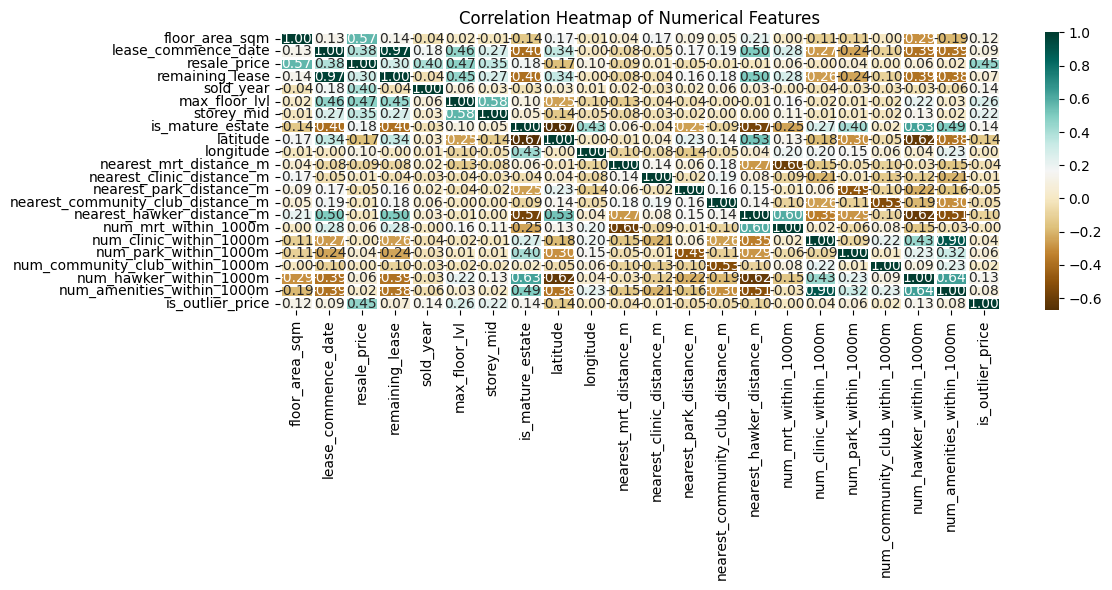

In [ ]:
print("\n" + "=" * 80)
print("CORRELATION HEATMAP")
print("=" * 80)

numerical_dataset = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

### Remarks on Data Loaded

The dataset contains 890,376 entries with a wide range of features. 

Here's a brief overview of some key numerical columns:
- **floor_area_sqm**: Ranges from 31 to 307 square meters.
- **lease_commence_date**: Ranges from 1966 to 2022.
- **resale_price**: Ranges from $5,000 to $1,500,000.
- **year**: Ranges from 1990 to 2023.
- **ResidentPopulation**: Ranges from about 2.74 million to 4.15 million.
- **Missing Values**: There are no columns with missing values in the dataset.



## Data Visualization  

### Counts of Resale Flats by Town, Flat Type, and Flat Model

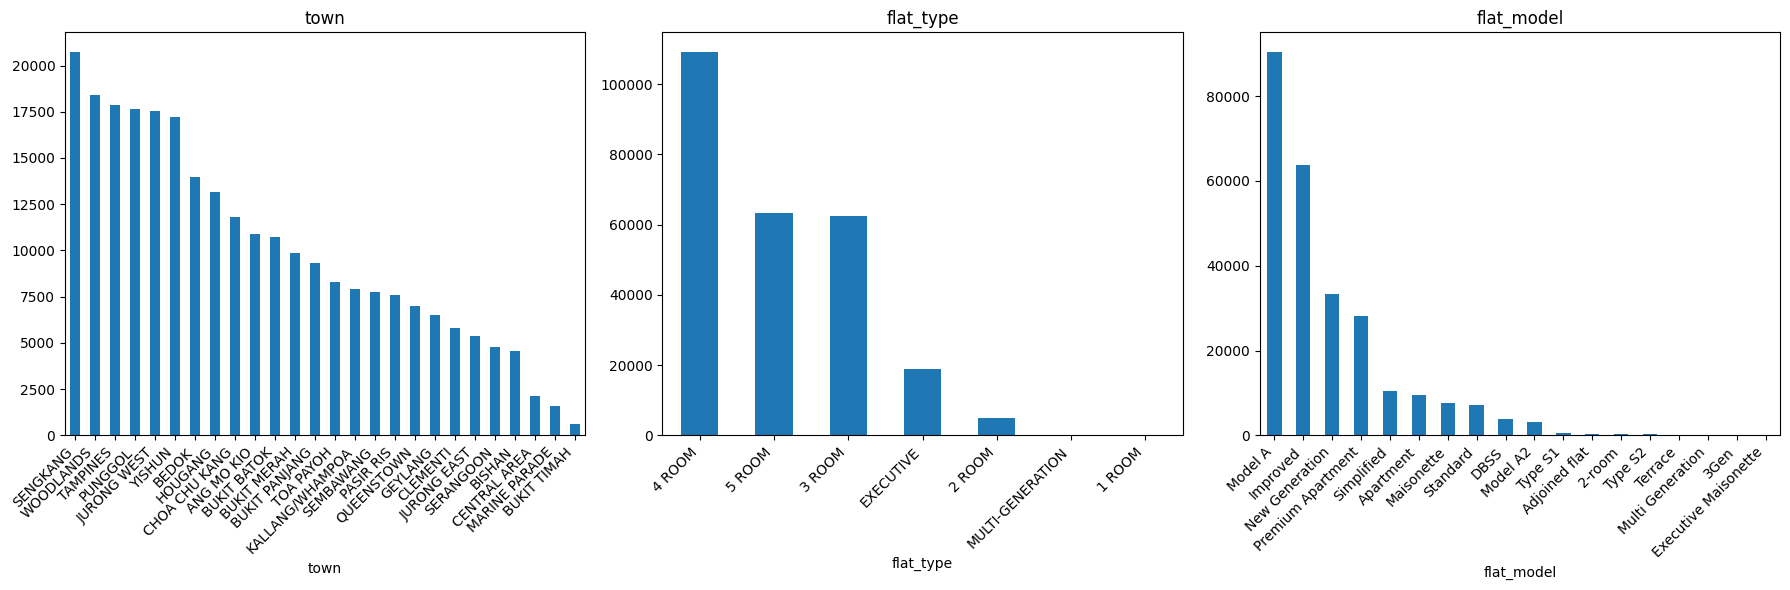

In [7]:
# Categorical Data Analysis
categorical_columns = ['town', 'flat_type', 'flat_model']

# Plotting distributions for categorical variables
plt.figure(figsize=(18, 6))

for i, column in enumerate(categorical_columns, 1):
    plt.subplot(1, 3, i)
    df[column].value_counts().plot(kind='bar')
    #plt.yscale("log")
    plt.title(column)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

**Observations**
- Town bar graph shows the frequency of properties across different towns. Some towns like Tampines and Yishun appear more frequently than others, indicating a higher number of transactions or listings in those areas.
- Flat type graph shows that 4 room HDB are the most resold type of HDB.
- Flat model graph shows that the vast majority of flats in singapore are of either Model A, Improved or New Generation type. Other models do not appear as much. 

### Boxplots of resale prices per year

In [8]:
# Create a box plot
fig = px.box(df, x='sold_year', y='resale_price',
             labels={'resale_price': 'Resale Price', 'year': 'Year'},
             title='Box Plot of Resale Price by Year')

# Set the x-axis tick mode to 'array' and set tick values explicitly
fig.update_xaxes(tickmode='array', tickvals=df['sold_year'].unique())

# Change the theme
fig.update_layout(template='plotly_dark')

**Observation**
- The graph is a box plot showing HDB resale prices from 1990 to 2023.
- The line in each box is the median price
- Box edges show where most prices fall each year.
- Lines sticking out show the normal highest and lowest prices.
- Dots far from the boxes are the outliers.
- The trend shows widgets becoming more valuable over time.
- Early on, from 1998 to around 2006, HDBs have a pretty tight price range.
- From 2004 onwards, you see those prices start to grow, with a significant increase in range and median price. 
- Outliers seem to grow more over time, often fetching prices way above the norm.

### Counts of each flat type sold over the years

In [9]:
# Group the data by 'year' and 'flat_type' and count the number of occurrences
flat_type_counts = df.groupby(['sold_year', 'flat_type']).size().reset_index(name='count')

# Calculate the sum of all sold properties for each year
total_sold_per_year = df.groupby('sold_year').size().reset_index(name='total_sold')

# Merge the total sold counts back into the flat_type_counts DataFrame
flat_type_counts = pd.merge(flat_type_counts, total_sold_per_year, on='sold_year', how='left')

# Create a line graph using Plotly Express
fig = px.line(flat_type_counts, x='sold_year', y='count', color='flat_type',
              color_discrete_sequence=px.colors.qualitative.Light24, markers=True,
              labels={'count': 'Count', 'year': 'Year'},
              title='Number of each type of flat sold per year')

# Add a line for the total sold properties
fig.add_trace(px.line(flat_type_counts, x='sold_year', y='total_sold', labels='Total', markers=True,).data[0])

# Change yaxis scale
fig.update_yaxes(type='log')

# Change the theme
fig.update_layout(template='plotly_dark')

**Observation**
- Total sold from the year is missing from the legend
- 4 Room flats consistently have the highest sales count across the years.
- Sales of 1 Room and Multi Generation flats are the lowest.
- Sales of 2, 3, 4, 5 Room & Executive flats show relative stability with fluctuations but no clear long-term upward or downward trend.
- There's a slight dip in sales for most flat types around 2021, except for 2 Room flats.

### Median resale price of each type of flat over the years

In [10]:
# Group the data by 'year' and 'flat_type' and count the number of occurrences
flat_type_median = df.groupby(['sold_year', 'flat_type'])['resale_price'].median().reset_index(name='median_price')

# Create a line graph using Plotly Express
fig = px.line(flat_type_median, x='sold_year', y='median_price', color='flat_type',
              color_discrete_sequence=px.colors.qualitative.Light24, markers=True,
              labels={'median_price': 'Median Price', 'year': 'Year'},
              title='Median resale price of each type of flat over the years')



# Change the theme
fig.update_layout(template='plotly_dark')
#fig.update_xaxes(rangeslider_visible=True)

**Observation** 
- All flat types show an overall increasing trend in median resale price over time. 
- The slight dip in prices from '96 - '97 are possibly caused by the cooling measures introduced and the asian financial crisis. Likewise with the dip in 2013 when more cooling measures were introduced*.
- The 5 Room and Executive flats show the most significant increase in median price, particularly from the late 2000s onwards.
- Multi Generation flats show a steep increase in median price starting around the late 2000s, surpassing all other flat types by 2025.
- The 1 Room flats have the lowest median resale price across the timeline, with a more gradual increase.
- The price increase rate for 2 Room and 3 Room flats is moderate but consistent.
- The 4 Room flats' median price remains in the mid-range among the flat types and follows a steady growth pattern.

*Source: https://www.businesstimes.com.sg/property/mobile-spotlight/summary-singapores-property-cooling-measures-1996-present-day

In [11]:
oldest = df['lease_commence_date'].min()
df_earliest_lease = df[df['lease_commence_date'] == oldest + 4 ]
lease_remaining = str(oldest + 4)

mean_resale_price = df_earliest_lease.groupby(['','sold_year'])['resale_price'].mean().reset_index()

from matplotlib.ticker import FuncFormatter
def with_commas(x, pos):
    return "{:,}".format(int(x))

# Create the line plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=mean_resale_price, x='remaining_lease', y='resale_price')
sns.set_theme(style = 'darkgrid')
plt.title('Mean Resale Price from 1990 - 2023, for Flats with 99 year Lease Starting in ' + lease_remaining)
plt.xlabel('Lease Remaining')
plt.ylabel('Mean Resale Price ($SGD)')
plt.gca().invert_xaxis()
plt.gca().yaxis.set_major_formatter(FuncFormatter(with_commas))
plt.show()

KeyError: ''